Run this to activate virtual env

bash

source /mnt/data2/le000415/.venv/bin/activate

In [57]:
import tifffile as tiff
import matplotlib.pyplot as plt
import numpy as np

img_after_tor5 = tiff.imread("/mnt/data2/le000415/Prof_Ding_Lab/OU_Datasets/TOR5_BEST_AFTER_win50d.tif")

print(img_after_tor5.shape)
print(img_after_tor5.dtype)
print(np.nanmin(img_after_tor5), np.nanmax(img_after_tor5))

(402, 639, 6)
float32
-0.003705 0.6036325


In [58]:
import numpy as np

print("dtype:", img_after_tor5.dtype)
print("Total elements:", img_after_tor5.size)
print("NaN count:", np.isnan(img_after_tor5).sum())
print("NaN percent:", 100*np.isnan(img_after_tor5).mean(), "%")


dtype: float32
Total elements: 1541268
NaN count: 9906
NaN percent: 0.6427175546368314 %


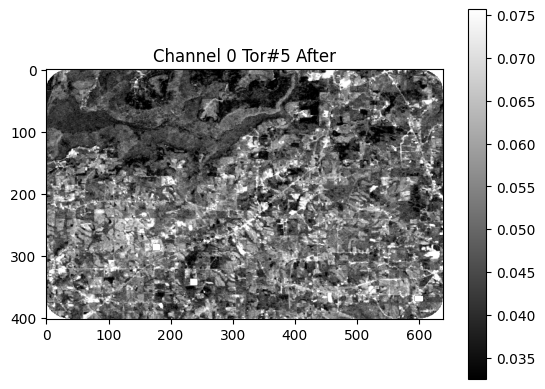

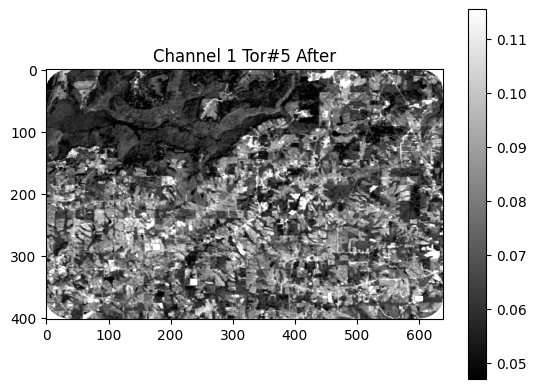

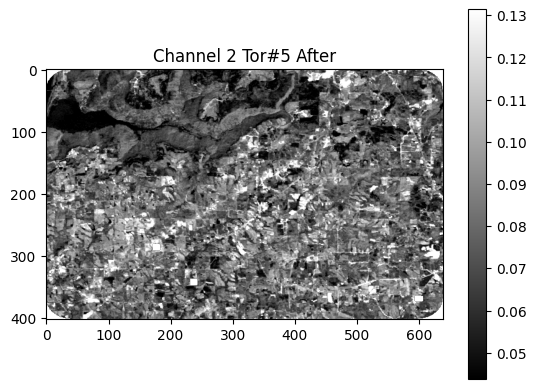

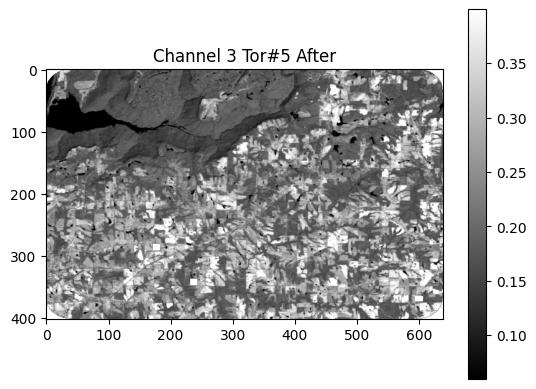

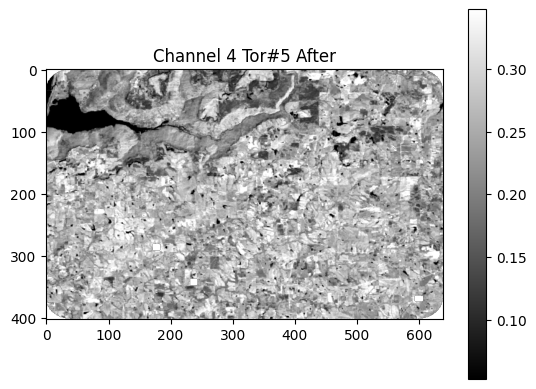

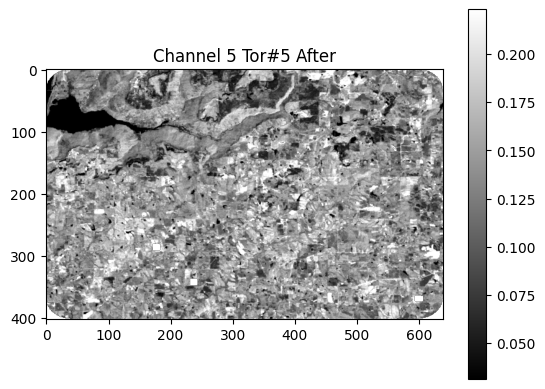

In [59]:
for c in range(6):
    ch = img_after_tor5[:, :, c].astype(np.float32)

    vmin = np.nanpercentile(ch, 2)
    vmax = np.nanpercentile(ch, 98)

    plt.imshow(ch, cmap="gray", vmin=vmin, vmax=vmax)
    plt.colorbar()
    plt.title(f"Channel {c} Tor#5 After")
    plt.show()


In [60]:
import numpy as np

print("dtype:", img_after_tor5.dtype)
print("Total elements:", img_after_tor5.size)
print("NaN count:", np.isnan(img_after_tor5).sum())
print("NaN percent:", 100*np.isnan(img_after_tor5).mean(), "%")


dtype: float32
Total elements: 1541268
NaN count: 9906
NaN percent: 0.6427175546368314 %


In [61]:
for c in range(6):
    ch = img_after_tor5[:,:,c]
    print(
        f"Channel {c}:",
        "min =", np.nanmin(ch),
        "max =", np.nanmax(ch),
        "mean =", np.nanmean(ch),
        "std =", np.nanstd(ch)
    )


Channel 0: min = 0.02187 max = 0.2766025 mean = 0.050223902 std = 0.010819877
Channel 1: min = 0.03034 max = 0.2916175 mean = 0.073556624 std = 0.017935093
Channel 2: min = 0.02572 max = 0.365565 mean = 0.079591356 std = 0.021536926
Channel 3: min = 0.015215 max = 0.5646925 mean = 0.22334963 std = 0.07460501
Channel 4: min = -0.003705 max = 0.6036325 mean = 0.24173257 std = 0.0621222
Channel 5: min = -0.0014775 max = 0.5412625 mean = 0.13826396 std = 0.04190226


In [62]:
flat = img_after_tor5.reshape(-1, 6)
flat = flat[np.all(np.isfinite(flat), axis=1)]  # remove NaN rows

print("TOR5_BEST_AFTER_win50d")
corr = np.corrcoef(flat.T)
print(corr)


TOR5_BEST_AFTER_win50d
[[1.         0.92691196 0.92408727 0.43586314 0.704782   0.75918613]
 [0.92691196 1.         0.90804997 0.60968721 0.68969264 0.69284562]
 [0.92408727 0.90804997 1.         0.38471281 0.80681353 0.86754683]
 [0.43586314 0.60968721 0.38471281 1.         0.50323584 0.29262491]
 [0.704782   0.68969264 0.80681353 0.50323584 1.         0.94369522]
 [0.75918613 0.69284562 0.86754683 0.29262491 0.94369522 1.        ]]


In [63]:
import tifffile as tiff
import matplotlib.pyplot as plt
import numpy as np

img_before_tor5 = tiff.imread("/mnt/data2/le000415/Prof_Ding_Lab/OU_Datasets/TOR5_BEST_BEFORE_win20d.tif")

print(img_before_tor5.shape)
print(img_before_tor5.dtype)
print(np.nanmin(img_before_tor5), np.nanmax(img_before_tor5))

(402, 639, 6)
float32
-0.002 0.55031


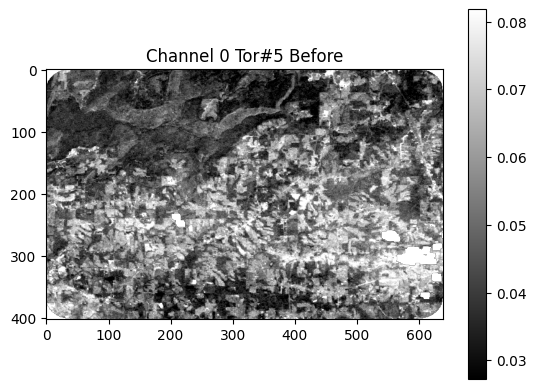

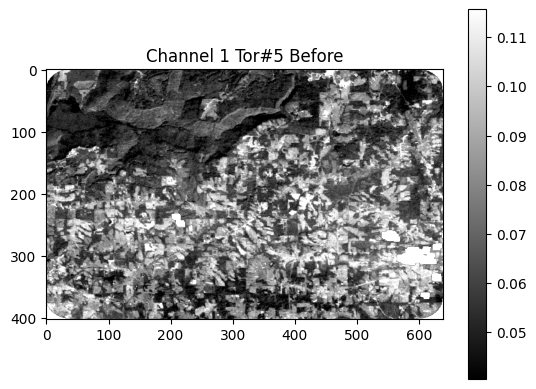

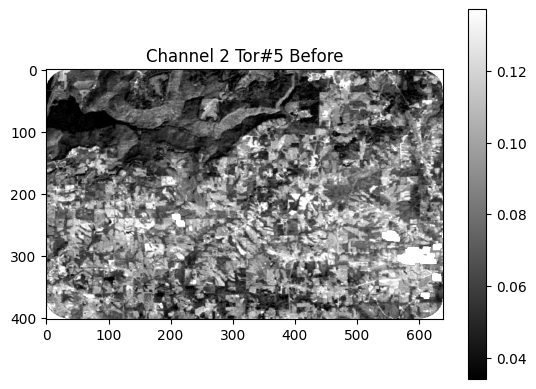

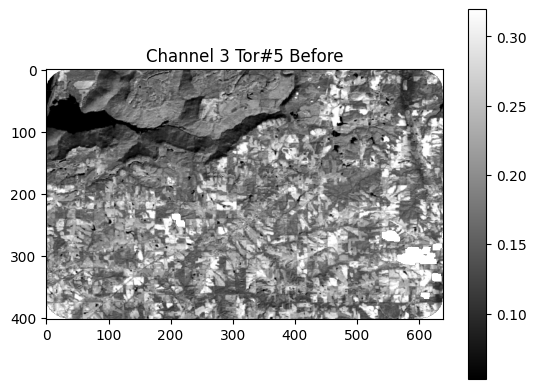

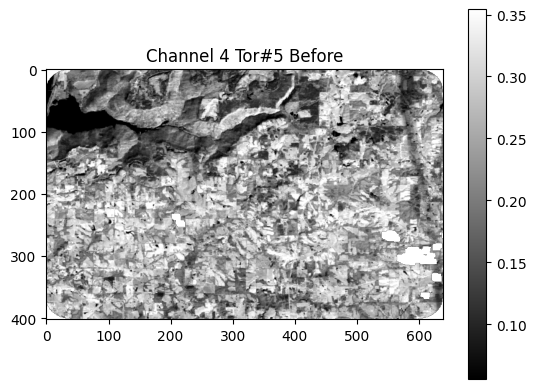

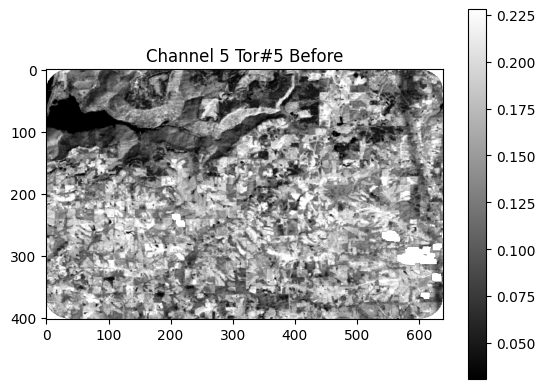

In [64]:
for c in range(6):
    ch = img_before_tor5[:, :, c].astype(np.float32)

    vmin = np.nanpercentile(ch, 2)
    vmax = np.nanpercentile(ch, 98)

    plt.imshow(ch, cmap="gray", vmin=vmin, vmax=vmax)
    plt.colorbar()
    plt.title(f"Channel {c} Tor#5 Before")
    plt.show()

In [65]:
flat = img_before_tor5.reshape(-1, 6)
flat = flat[np.all(np.isfinite(flat), axis=1)]  # remove NaN rows

print("TOR5_BEST_BEFORE_win20d")
corr = np.corrcoef(flat.T)
print(corr)

TOR5_BEST_BEFORE_win20d
[[1.         0.93226546 0.92181465 0.63171117 0.776887   0.82080988]
 [0.93226546 1.         0.95198049 0.74108545 0.81609155 0.84411882]
 [0.92181465 0.95198049 1.         0.69496233 0.88993545 0.91973895]
 [0.63171117 0.74108545 0.69496233 1.         0.75488587 0.67958201]
 [0.776887   0.81609155 0.88993545 0.75488587 1.         0.97547217]
 [0.82080988 0.84411882 0.91973895 0.67958201 0.97547217 1.        ]]


In [66]:
img_after = tiff.imread("/mnt/data2/le000415/Prof_Ding_Lab/OU_Datasets/TOR5_BEST_AFTER_win50d.tif")
img_before = tiff.imread("/mnt/data2/le000415/Prof_Ding_Lab/OU_Datasets/TOR5_BEST_BEFORE_win20d.tif")

diff = img_after - img_before

for c in range(6):
    ch = diff[:,:,c]
    print(
        f"Channel {c}:",
        "mean diff =", np.nanmean(ch),
        "std diff =", np.nanstd(ch)
    )


Channel 0: mean diff = -0.0009028062 std diff = 0.00908814
Channel 1: mean diff = 0.0013980968 std diff = 0.010922079
Channel 2: mean diff = -0.00019936459 std diff = 0.016256362
Channel 3: mean diff = 0.037170343 std diff = 0.030505875
Channel 4: mean diff = 0.014838431 std diff = 0.041488215
Channel 5: mean diff = 0.0010279779 std diff = 0.033281952


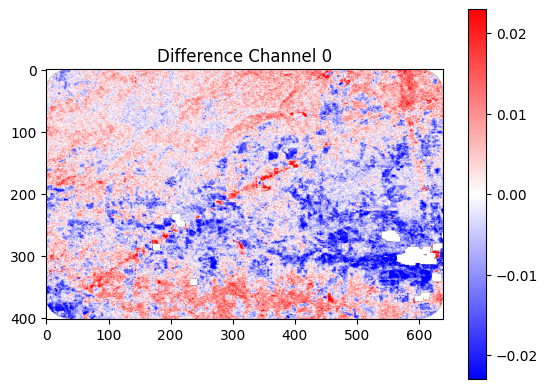

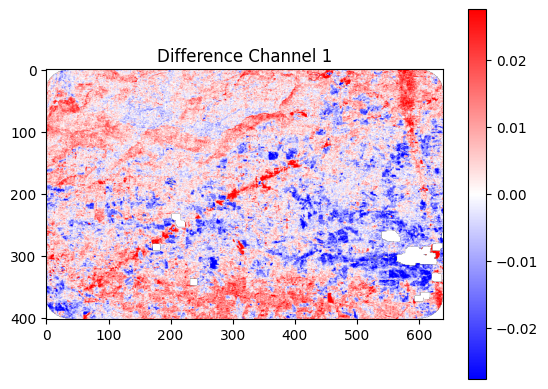

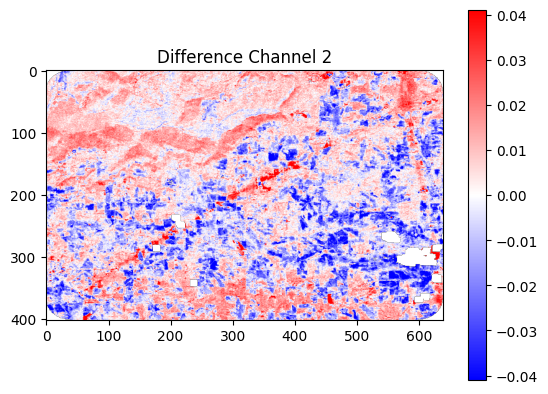

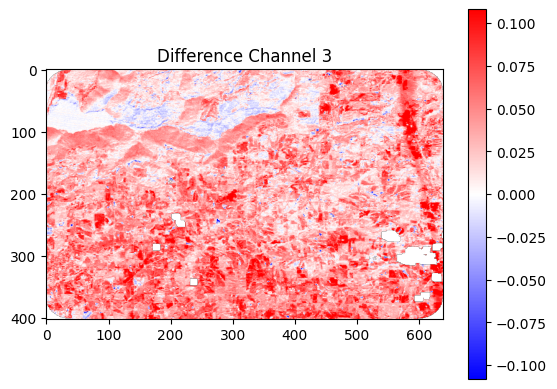

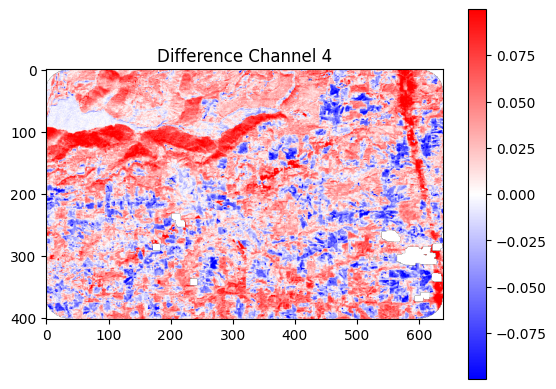

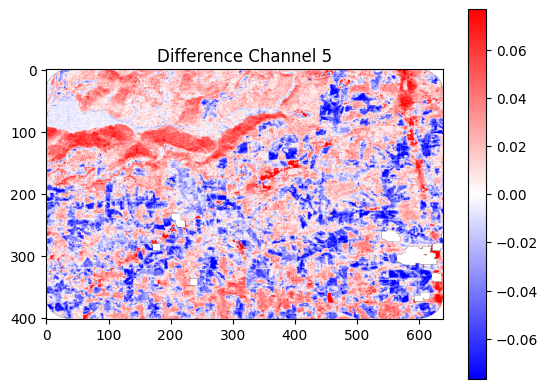

In [67]:
for c in range(6):
    ch = diff[:,:,c]

    v = np.nanpercentile(np.abs(ch), 98)

    plt.imshow(ch, cmap='bwr', vmin=-v, vmax=v)
    plt.colorbar()
    plt.title(f"Difference Channel {c}")
    plt.show()


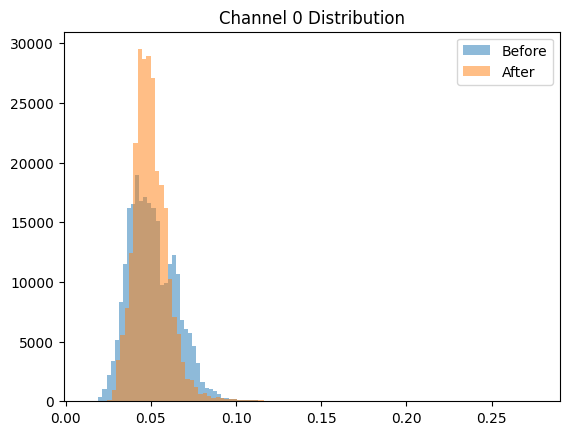

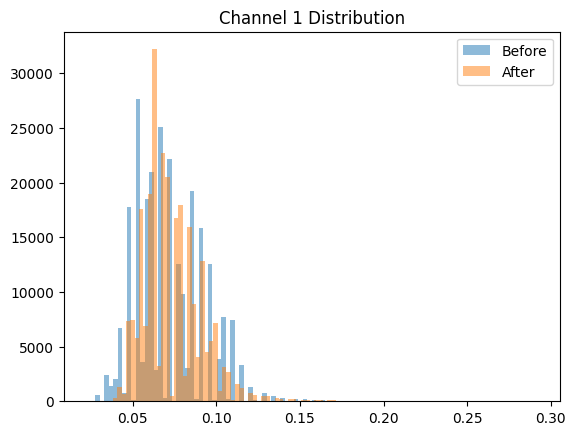

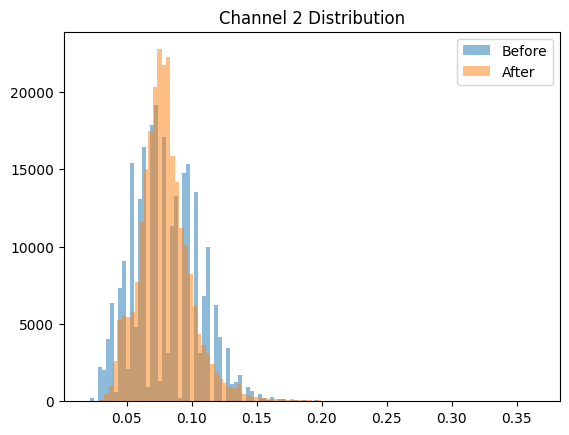

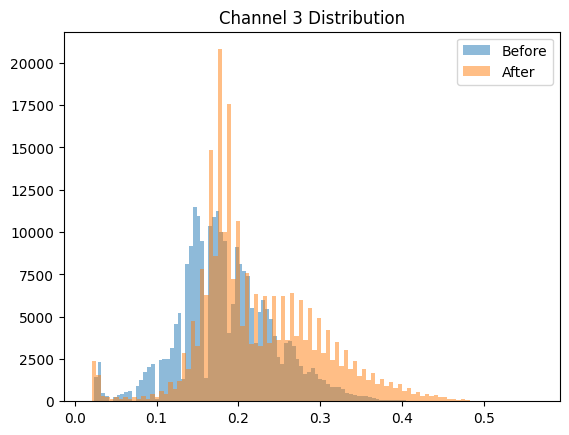

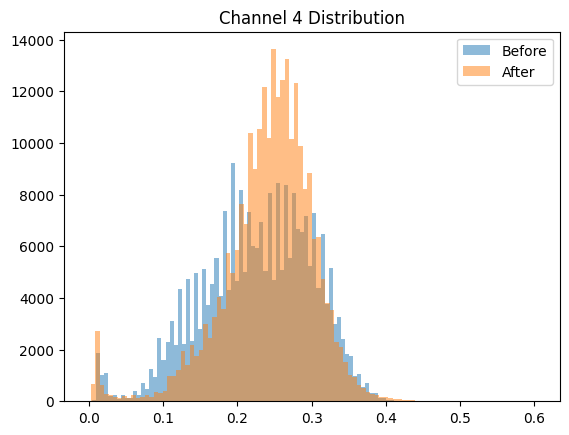

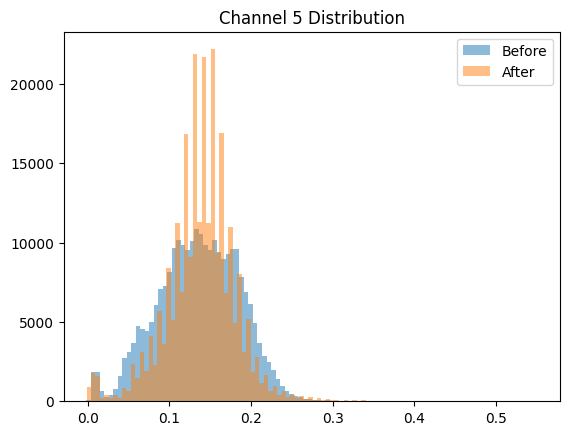

In [68]:
import matplotlib.pyplot as plt

for c in range(6):
    plt.hist(img_before[:,:,c].ravel(), bins=100, alpha=0.5, label="Before")
    plt.hist(img_after[:,:,c].ravel(), bins=100, alpha=0.5, label="After")
    plt.legend()
    plt.title(f"Channel {c} Distribution")
    plt.show()


In [69]:
from sklearn.decomposition import PCA

flat = img_after.reshape(-1,6)
flat = flat[np.all(np.isfinite(flat), axis=1)]

pca = PCA()
pca.fit(flat)

print("Explained variance ratio:", pca.explained_variance_ratio_)


Explained variance ratio: [7.0230347e-01 2.6723418e-01 2.5382956e-02 3.3815838e-03 1.0124329e-03
 6.8545516e-04]


In [70]:
import numpy as np

for c in range(6):
    ch1 = img_before_tor5[:, :, c]
    ch2 = img_after_tor5[:, :, c]

    
    mean_val_before = np.nanmean(ch1)
    var_val_before  = np.nanvar(ch1)
    std_val_before  = np.nanstd(ch1)

    mean_val_after = np.nanmean(ch2)
    var_val_after  = np.nanvar(ch2)
    std_val_after  = np.nanstd(ch2)
    
    print(f"Channel {c}:")
    print("  mean_before =", mean_val_before, "  mean_after =", mean_val_after)
    print("  variance_before =", var_val_before, "  variance_after =", var_val_after)
    # print("  std_before =", std_val_before, "  std_after =", std_val_after)
    print()


Channel 0:
  mean_before = 0.051094   mean_after = 0.050223902
  variance_before = 0.00020452341   variance_after = 0.00011706973

Channel 1:
  mean_before = 0.07210457   mean_after = 0.073556624
  variance_before = 0.00042643325   variance_after = 0.00032166758

Channel 2:
  mean_before = 0.07971262   mean_after = 0.079591356
  variance_before = 0.0006864973   variance_after = 0.00046383915

Channel 3:
  mean_before = 0.1861135   mean_after = 0.22334963
  variance_before = 0.0035283542   variance_after = 0.0055659073

Channel 4:
  mean_before = 0.22687523   mean_after = 0.24173257
  variance_before = 0.0055332286   variance_after = 0.0038591677

Channel 5:
  mean_before = 0.13717853   mean_after = 0.13826396
  variance_before = 0.0024334162   variance_after = 0.0017557992



In [71]:
import numpy as np

print("dtype:", img_after_tor5.dtype)
print("Total elements:", img_after_tor5.size)
print("NaN count:", np.isnan(img_after_tor5).sum())
print("NaN percent:", 100*np.isnan(img_after_tor5).mean(), "%")


dtype: float32
Total elements: 1541268
NaN count: 9906
NaN percent: 0.6427175546368314 %


In [72]:
import numpy as np

print("dtype:", img_after_tor5.dtype)
print("Total elements:", img_after_tor5.size)
print("NaN count:", np.isnan(img_after_tor5).sum())
print("NaN percent:", 100*np.isnan(img_after_tor5).mean(), "%")


dtype: float32
Total elements: 1541268
NaN count: 9906
NaN percent: 0.6427175546368314 %


In [73]:
import os
import numpy as np
import tifffile as tiff

folder_path = "/mnt/data2/le000415/Prof_Ding_Lab/OU_Datasets"
i = 1
for filename in os.listdir(folder_path):
    print(i)
    i += 1
    if filename.endswith(".tif"):
        file_path = os.path.join(folder_path, filename)
        
        print("\n==============================")
        print("File:", filename)
        
        img = tiff.imread(file_path)
        
        print("shape:", img.shape)
        print("dtype:", img.dtype)
        print("NaN %:", np.isnan(img).mean())
        
        # safer min/max using nan-aware functions
        print("min:", np.nanmin(img))
        print("max:", np.nanmax(img))


1

File: TOR12_BEST_BEFORE_win25d.tif
shape: (1089, 1601, 6)
dtype: float32
NaN %: 0.001903080547109847
min: -0.0085175
max: 1.6022125
2

File: TOR7_BEST_AFTER_win45d.tif
shape: (1618, 2483, 6)
dtype: float32
NaN %: 0.010234987283117286
min: -0.0092325
max: 1.6022125
3

File: TOR15_BEST_BEFORE_win25d.tif
shape: (1189, 2566, 6)
dtype: float32
NaN %: 0.0005781760185435864
min: -0.008215
max: 1.6022125
4

File: TOR68_BEST_BEFORE_win55d.tif
shape: (2324, 3393, 6)
dtype: float32
NaN %: 0.006336004622253064
min: -0.199285
max: 1.599985
5

File: TOR12_BEST_AFTER_win10d.tif
shape: (1089, 1601, 6)
dtype: float32
NaN %: 0.0013100168684746505
min: -0.008545
max: 1.6022125
6

File: TOR7_BEST_BEFORE_win25d.tif
shape: (1618, 2483, 6)
dtype: float32
NaN %: 0.015289630799697524
min: -0.01003
max: 1.6022125
7

File: TOR18_BEST_AFTER_win20d.tif
shape: (1600, 2429, 6)
dtype: float32
NaN %: 0.046252058460271715
min: -0.01047
max: 1.6022125
8

File: TOR5_BEST_AFTER_win50d.tif
shape: (402, 639, 6)
dtype: fl